# NVDA in 2025 — A Forecasting Case Study

> **Part 1 of 6.** Next: [`02_intro_agentic_predictor.ipynb`](02_intro_agentic_predictor.ipynb).

Suppose your book is heavily exposed to NVIDIA. Every Monday of 2025 you forecast its
close 5, 10 and 21 trading days ahead with **AutoARIMA**, a standard statistical model,
fitted on the whole price history. It produces a central forecast and an 80% interval.

NVDA is the market's AI bellwether, and in 2025 it moved like one: export controls,
tariffs, a Chinese model release and its own earnings all produced single-session moves
of 5% or more.

This notebook asks: *how well does a price-only model do on a stock like this, and what
would a better forecaster need to know?*

> Run from the `implementations/` directory after `uv run python scripts/fetch_nvda.py`
> has populated the price cache. Everything here reads committed results, so it runs in
> seconds and calls no LLM.

In [1]:
import warnings
from datetime import datetime


warnings.filterwarnings("ignore")

import pandas as pd
from ai_stocks_forecasting.charts import coverage_sharpness_table, load_scored_frame, predicted_vs_actual
from ai_stocks_forecasting.data import NVDA_SERIES_ID, build_nvda_service
from ai_stocks_forecasting.story import describe_shocks, price_story, shock_days, shock_window_crps


pd.set_option("display.width", 160)
BASELINES = ["Naive (last value)", "AutoARIMA (log returns)"]

## Load NVDA price data

The series is NVDA's **split-adjusted** daily close from Yahoo Finance. Adjustment
matters here: NVDA split 4-for-1 in 2021 and 10-for-1 in 2024, and on the raw close
those splits look like 75% and 90% one-day crashes.

In [2]:
data_service = build_nvda_service()
prices = data_service.get_series(NVDA_SERIES_ID, as_of=datetime.now())
frame = load_scored_frame("nvda_backtest", data_service)
baselines = frame[frame["predictor"].isin(BASELINES)]

print(
    f"Trading days loaded: {len(prices):,} ({prices['timestamp'].min():%Y-%m-%d} to {prices['timestamp'].max():%Y-%m-%d})"
)
print(f"2025 backtest: {baselines['as_of'].nunique()} weekly origins, {len(baselines)} scored baseline forecasts")

Trading days loaded: 6,967 (1999-01-22 to 2026-10-02)
2025 backtest: 51 weekly origins, 290 scored baseline forecasts


---

## Act 1 — Forecasting blind

Each point below is a 21-day AutoARIMA forecast, plotted at the date it was *forecasting*.
The shaded band is its 80% interval; the black line is what actually happened.
AutoARIMA sees only past prices. Fitted on log prices it becomes, in effect, a random walk
with drift: tomorrow looks like today, with uncertainty that grows with the horizon.

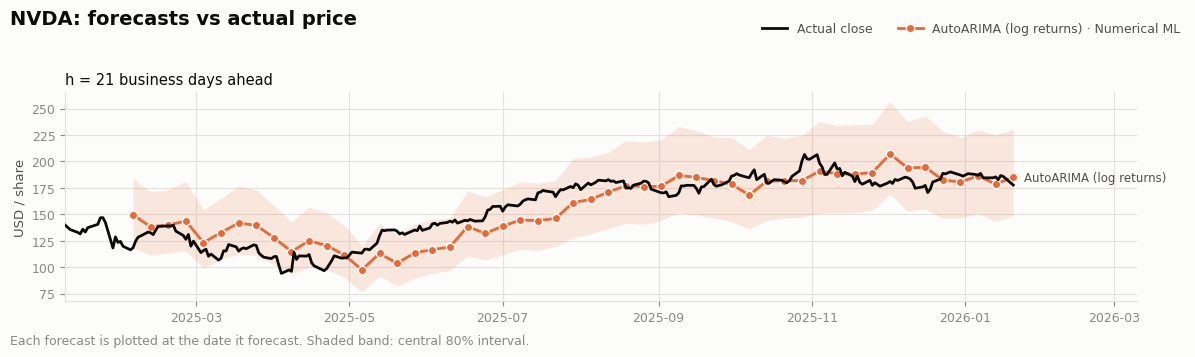

In [3]:
fig, axes = predicted_vs_actual(frame, data_service, horizons=(21,), predictors=["AutoARIMA (log returns)"])

**How to read it.** The forecast line is the actual line shifted three weeks to the right.
It never turns before the price does, and every sharp move (the January crash, the April
collapse and rebound) arrives as a surprise.

---

## Act 2 — The world context

These are the sessions where NVDA closed at least 5% away from the previous close. The
labelled ones have well-documented causes; none of them is in the price history the
model was fitted on.

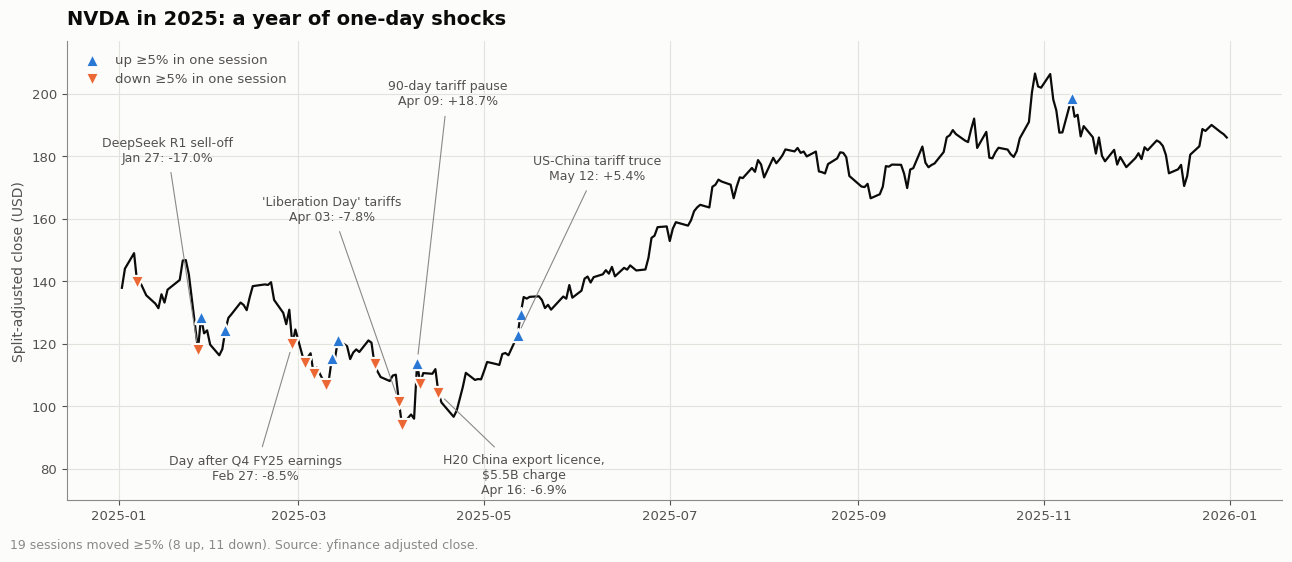

In [4]:
fig, ax = price_story(prices)

In [5]:
print(describe_shocks(prices, "2025-01-01", "2025-12-31"))
shock_days(prices.set_index(pd.to_datetime(prices["timestamp"]).dt.normalize())["value"], "2025-01-01", "2025-12-31")

{'sessions': 250, 'shock_sessions': 19, 'up': 8, 'down': 11, 'share_pct': 7.6}


,return_pct,close
timestamp,,
2025-01-07,-6.2,139.77
2025-01-27,-17.0,118.11
2025-01-28,8.9,128.65
2025-02-05,5.2,124.50
2025-02-27,-8.5,119.84
2025-03-03,-8.7,113.76
2025-03-06,-5.7,110.28
2025-03-10,-5.1,106.70
2025-03-12,6.4,115.45


Nineteen shock sessions in 250, clustered in the first half of the year. Each has a
cause a reader of the news could name: a competitor's model, a tariff schedule, an
export licence, an earnings report.

---

## Act 3 — How did the baseline do?

Two numbers per horizon: how often the 80% interval contained the outcome (*coverage*),
and **CRPS**, the error measure for a whole forecast distribution, in USD per share (lower
is better). The naive row repeats the last close with no interval, so its CRPS is just
its absolute error.

In [6]:
coverage_sharpness_table(baselines)

coverage_80  mean_width  mean_crps   n  miscalibration
family       predictor               horizon                                                        
Baseline     Naive (last value)      5               0.00        0.00       8.23  47           -80.0
                                     10              0.00        0.00      10.09  47           -80.0
                                     21              0.00        0.00      13.44  51           -80.0
Numerical ML AutoARIMA (log returns) 5              82.98       32.83       6.25  47             3.0
                                     10             89.36       46.53       7.60  47             9.4
                                     21             98.04       68.51      10.48  51            18.0

Now split the same error by whether a shock fell inside the forecast window:

In [7]:
shock_window_crps(baselines, prices)

window                           no shock  shock in window  windows with a shock (%)
predictor               horizon                                                     
AutoARIMA (log returns) 5            4.70             9.53                        32
                        10           6.63             9.31                        36
                        21           9.58            11.50                        47
Naive (last value)      5            5.87            13.25                        32
                        10           8.48            12.94                        36
                        21          11.97            15.09                        47

### What happened?

- **AutoARIMA's intervals are honest but wide.** Its 80% band contained the outcome 83%,
  89% and 98% of the time at 5, 10 and 21 days, at an average width of \$33 to \$69 per
  share on a stock trading around \$100 to \$200. It is right mostly because it is vague.
- **The error lives in the shock windows.** At 5 days, AutoARIMA's CRPS is 4.7 in a quiet
  week and 9.5 in a week with a shock, about double. The naive forecast goes from 5.9
  to 13.3. Roughly a third of 5-day windows and almost half of 21-day windows contain a
  shock.
- **It beats naive everywhere**, because an honest wide distribution scores better than
  a point that is wrong.

> A model that only knows prices treats every shock as noise. To do better, a forecaster
> needs to know *why* the stock moves.

---

## Act 4 — What could have helped?

### Five levers a better forecaster could pull

| Information source | What it adds | Limitation |
|---|---|---|
| **Earnings calendar** | The single biggest scheduled risk: an earnings reaction session is a ±5% shock about 50% of the time, against 12% for an average session (2020–2024) | Says *when*, not which direction |
| **Policy news** (export controls, tariffs) | The cause of most of 2025's largest moves | Unscheduled; needs reasoning to connect to the stock |
| **Industry news** (hyperscaler capex, competitor models) | Demand signals for AI accelerators | Noisy, and much of it is already priced in |
| **Options-implied volatility** | The market's own forecast of how much the stock will move | Not in our data yet; it is a Phase 4 extension |
| **Recent volatility regime** | Shocks cluster: the chance of a shock rises from 5.5% to 18.8% between low- and high-volatility regimes | Reactive: it says shocks are likely, not when |

### Four forecasting method families

| Family | Example here | Uses news? |
|---|---|---|
| **Numerical** | Naive, AutoARIMA | No |
| **LLM process** | An LLM asked for quantiles directly | Only what it memorised |
| **News-grounded agent** | The NVDA analyst agent with cutoff-fenced web search | Yes, live and fenced |
| **Adaptive agent** | The agent plus statistically graduated news patterns (Phase 2) | Yes, plus learned rules |

### So — can an agent do better?

The next notebook puts the news-grounded agent next to the two baselines on the same
origins and looks at what it actually says.